In [207]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [239]:
# getting to know the pytorch lib with about the same ex as in lesson

In [240]:
# xs, 4 random mock values embedded into 4 dimensions
# ys, 4 label values
xs = torch.randn(4, 4)
ys = torch.tensor([1.,0.,0.,1.])

In [241]:
xs, ys

(tensor([[ 0.7386,  0.1913, -1.0394, -1.1989],
         [-2.0524,  1.8620, -1.4141,  0.2718],
         [-0.7349,  0.0806, -0.2715,  0.1758],
         [ 0.0300, -0.5253,  1.2027,  0.9358]]),
 tensor([1., 0., 0., 1.]))

In [242]:
# initialize layers
W1 = torch.randn(4, 10)
b1 = torch.randn(10)
W2 = torch.randn(10, 1)
b2 = torch.randn(1)


In [243]:
params = [W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

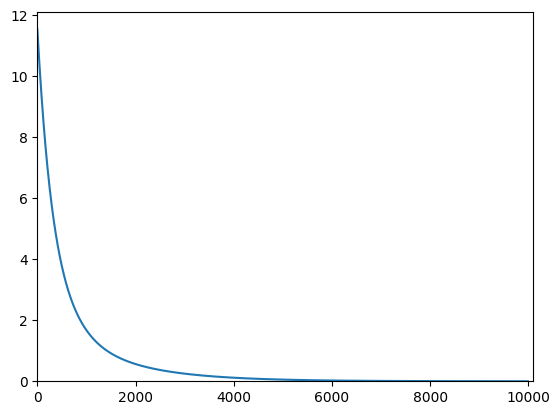

In [244]:
# forward pass

# tracking
n = []
losses = []

for i in range(10000):
    a = xs @ W1 + b1
    s = torch.tanh(a)
    logits = s @ W2 + b2
    loss = F.mse_loss(logits.view(-1).float(), ys.float())
    for p in params:
        p.grad = None
    loss.backward()

    for p in params:
        p.data += -0.0001 * p.grad
    
    n.append(i)
    losses.append(loss.item())

    if i % 10 == 0:
        clear_output(wait=True)
        plt.plot(n, losses)
        plt.xlim(0, 10100)
        plt.ylim(bottom=0)
        plt.show()

In [245]:
loss.item()

0.001083132578060031

In [246]:
for p in logits:
    print(p.item())

0.9637031555175781
-0.02316904067993164
0.04286026954650879
0.9746768474578857


In [247]:
ys

tensor([1., 0., 0., 1.])